# NSW Transit Weather Resilience — Exploratory Data Analysis

Exploratory analysis of ~14 days of collected data across:
- **12M+** GTFS-R transit update ticks
- **8 BOM stations** × 15-minute weather observations
- **7M+** vehicle position records

In [2]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

sys.path.insert(0, str(Path("..").resolve()))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

PARQUET_DIR = Path("../data/parquet")

## 1. Data Audit

In [3]:
con = duckdb.connect()

files = {
    "transit_updates": {
        "path": PARQUET_DIR / "transit_updates.parquet",
        "cols": ["trip_id", "route_id", "stop_id", "timestamp", "delay_seconds", "is_incident_active", "schedule_relationship", "vehicle_id"],
    },
    "weather_observations": {
        "path": PARQUET_DIR / "weather_observations.parquet",
        "cols": ["timestamp", "station_id", "station_label", "air_temp_c", "rain_trace_mm", "wind_gust_kmh"],
    },
    "vehicle_positions": {
        "path": PARQUET_DIR / "vehicle_positions.parquet",
        "cols": ["timestamp", "vehicle_id", "occupancy_status", "latitude", "longitude"],
    },
    "active_alerts": {
        "path": PARQUET_DIR / "active_alerts.parquet",
        "cols": ["timestamp", "route_id", "cause"],
    },
}

for name, info in files.items():
    glob_pattern = str(PARQUET_DIR / f"{name}*.parquet")
    shards = sorted(PARQUET_DIR.glob(f"{name}*.parquet"))
    if not shards:
        print(f"{'='*60}")
        print(f"Dataset: {name}  — NO FILES FOUND (skipped)")
        continue
    row_count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{glob_pattern}')").fetchone()[0]
    df = pd.concat([pd.read_parquet(p, columns=info["cols"]) for p in shards], ignore_index=True)
    ts_col = "timestamp"
    print(f"{'='*60}")
    print(f"Dataset: {name}  ({len(shards)} shard(s))")
    print(f"  Rows (duckdb): {row_count:,}")
    print(f"  Shape (pandas): {df.shape}")
    if ts_col in df.columns:
        ts = pd.to_datetime(df[ts_col], utc=True)
        print(f"  Timestamp range: {ts.min()} -> {ts.max()} (UTC)")
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    if len(null_counts) > 0:
        print("  Null counts (non-zero columns):")
        for col, cnt in null_counts.items():
            print(f"    {col}: {cnt:,} ({cnt/len(df)*100:.2f}%)")
    else:
        print("  Null counts: none")

print(f"{'='*60}")
print("\nschedule_relationship value counts (all transit_updates shards):")
glob_pattern = str(PARQUET_DIR / "transit_updates*.parquet")
tu_rel = con.execute(
    f"SELECT schedule_relationship, COUNT(*) AS cnt FROM read_parquet('{glob_pattern}')"
    " GROUP BY schedule_relationship ORDER BY cnt DESC"
).df()
print(tu_rel.to_string(index=False))

Dataset: transit_updates  (2 shard(s))
  Rows (duckdb): 19,313,543
  Shape (pandas): (19313543, 8)
  Timestamp range: 2026-03-31 08:42:36.803677+00:00 -> 2026-04-21 06:36:58.119994+00:00 (UTC)
  Null counts (non-zero columns):
    stop_id: 639,613 (3.31%)
    delay_seconds: 2,225,603 (11.52%)
    vehicle_id: 19,313,543 (100.00%)
Dataset: weather_observations  (2 shard(s))
  Rows (duckdb): 7,822
  Shape (pandas): (7822, 6)
  Timestamp range: 2026-03-31 07:00:00+00:00 -> 2026-04-21 06:00:00+00:00 (UTC)
  Null counts (non-zero columns):
    air_temp_c: 974 (12.45%)
    rain_trace_mm: 1,004 (12.84%)
    wind_gust_kmh: 962 (12.30%)
Dataset: vehicle_positions  (2 shard(s))
  Rows (duckdb): 10,896,601
  Shape (pandas): (10896601, 5)
  Timestamp range: 2026-03-31 08:42:36.803677+00:00 -> 2026-04-21 06:37:13.127983+00:00 (UTC)
  Null counts: none
Dataset: active_alerts  (2 shard(s))
  Rows (duckdb): 69,303,930
  Shape (pandas): (69303930, 3)
  Timestamp range: 2026-03-31 07:08:16.803180+00:00 -

## 2. Delay Distribution

Loaded 2 shard(s) — 19,313,543 rows total


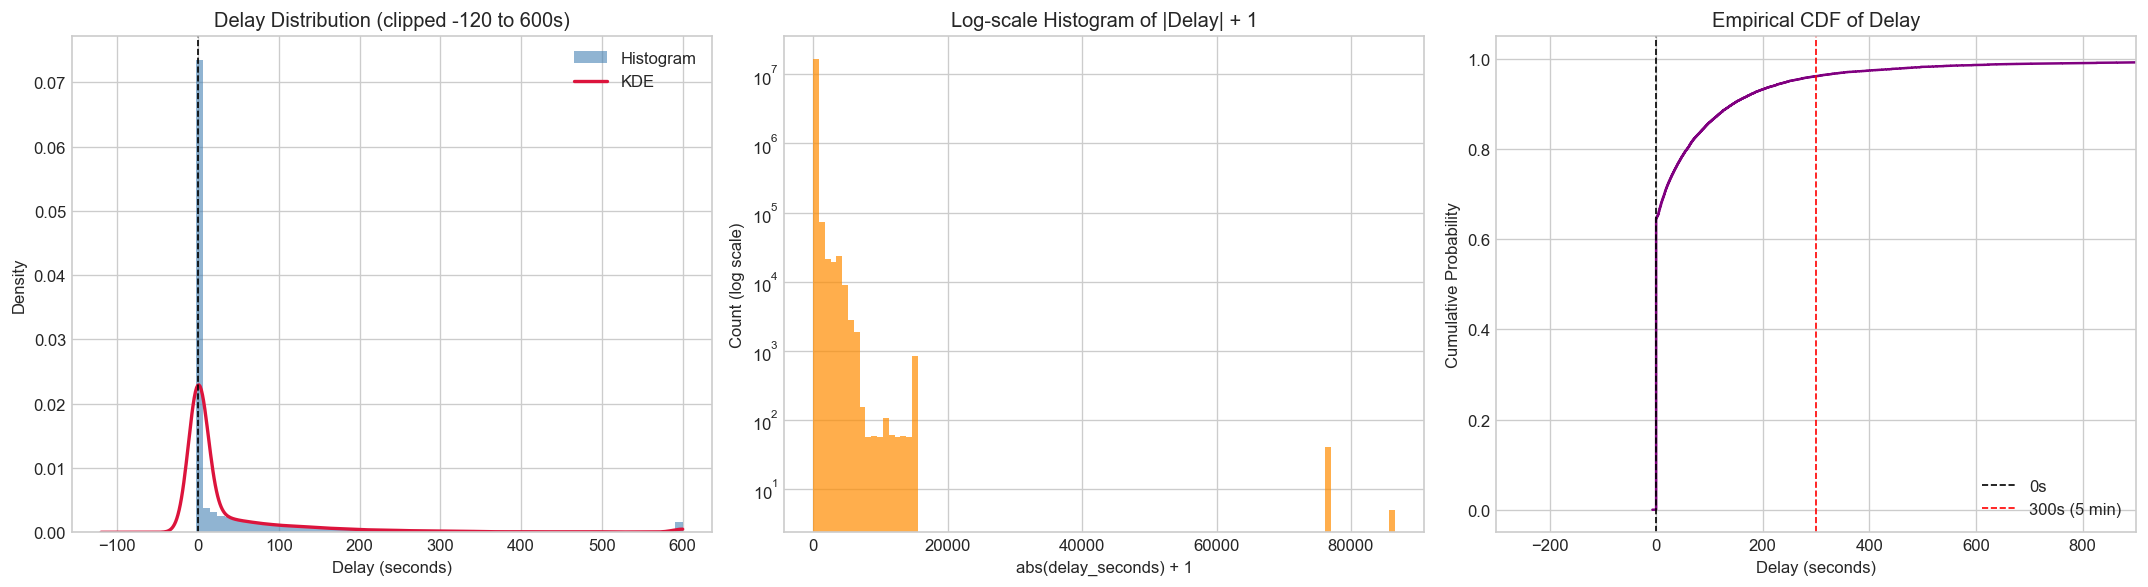

Delay Statistics (n=17,087,940):
  Median:                 0.0 s
  Mean:                   60.8 s
  95th percentile:        250.0 s
  99th percentile:        799.0 s
  Fraction on-time (<60s):80.30%
  Significantly delayed (>300s): 3.89%


In [18]:
# Read all transit_updates shards (transit_updates.parquet, _2.parquet, …)
_shards = sorted(PARQUET_DIR.glob("transit_updates*.parquet"))
tu = pd.concat(
    [pd.read_parquet(p, columns=["schedule_relationship", "delay_seconds"]) for p in _shards],
    ignore_index=True
)
print(f"Loaded {len(_shards)} shard(s) — {len(tu):,} rows total")
tu = tu[
    (tu["schedule_relationship"] != "CANCELED") &
    (tu["delay_seconds"].notna())
].copy()
tu["delay_seconds"] = tu["delay_seconds"].astype(float)

clipped = tu["delay_seconds"].clip(-120, 600)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Histogram with KDE overlay
ax = axes[0]
ax.hist(clipped, bins=80, density=True, alpha=0.6, color="steelblue", label="Histogram")
from scipy.stats import gaussian_kde
kde_vals = clipped.dropna()
kde = gaussian_kde(kde_vals.sample(min(50000, len(kde_vals)), random_state=42))
x_range = np.linspace(-120, 600, 500)
ax.plot(x_range, kde(x_range), color="crimson", lw=2, label="KDE")
ax.set_xlabel("Delay (seconds)")
ax.set_ylabel("Density")
ax.set_title("Delay Distribution (clipped -120 to 600s)")
ax.axvline(0, color="black", lw=1, ls="--")
ax.legend()

# (b) Log-scale histogram of abs(delay) + 1
ax = axes[1]
abs_delay = (tu["delay_seconds"].abs() + 1).dropna()
ax.hist(abs_delay, bins=100, color="darkorange", alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("abs(delay_seconds) + 1")
ax.set_ylabel("Count (log scale)")
ax.set_title("Log-scale Histogram of |Delay| + 1")

# (c) Empirical CDF
ax = axes[2]
sample = tu["delay_seconds"].dropna().sample(min(100000, len(tu)), random_state=42).sort_values()
cdf_y = np.arange(1, len(sample) + 1) / len(sample)
ax.plot(sample.values, cdf_y, color="purple", lw=1.5)
ax.axvline(0, color="black", lw=1, ls="--", label="0s")
ax.axvline(300, color="red", lw=1, ls="--", label="300s (5 min)")
ax.set_xlim(-300, 900)
ax.set_xlabel("Delay (seconds)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Empirical CDF of Delay")
ax.legend()

plt.tight_layout()
plt.show()

delays = tu["delay_seconds"].dropna()
print(f"Delay Statistics (n={len(delays):,}):")
print(f"  Median:                 {delays.median():.1f} s")
print(f"  Mean:                   {delays.mean():.1f} s")
print(f"  95th percentile:        {delays.quantile(0.95):.1f} s")
print(f"  99th percentile:        {delays.quantile(0.99):.1f} s")
on_time = (delays.abs() < 60).mean() * 100
sig_delayed = (delays > 300).mean() * 100
print(f"  Fraction on-time (<60s):{on_time:.2f}%")
print(f"  Significantly delayed (>300s): {sig_delayed:.2f}%")

## 2.1 Raw Outlier Analysis

GTFS-R feeds occasionally emit corrupt delay values caused by timestamp arithmetic errors (e.g. comparing a future scheduled time against an epoch-relative timestamp). These extreme outliers can reach ±21 hours and must be understood before any model training.

Task was destroyed but it is pending!
task: <Task pending name='Task-182' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/sandeepgautam/CDU/2026/research/tfnsw/project-implementation/.venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-183' coro=<Kernel.shell_main() running at /Users/sandeepgautam/CDU/2026/research/tfnsw/project-implementation/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/sandeepgautam/CDU/2026/research/tfnsw/project-implementation/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x1173da040>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-183' coro=<Kernel.shell_main() running at /Users/sandeepgautam/CDU/2026

Rows analysed (non-canceled, non-null delay): 17,087,940

Raw delay_seconds statistics:
  count   : 17,087,940.0 s
  mean    :         60.8 s
  std     :        316.9 s
  min     :    -76,387.0 s
  0.1%    :          0.0 s
  1%      :          0.0 s
  5%      :          0.0 s
  25%     :          0.0 s
  50%     :          0.0 s
  75%     :         33.0 s
  95%     :        250.0 s
  99%     :        799.0 s
  99.9%   :      4,096.0 s
  max     :     86,520.0 s

Outliers outside [0, 3600] s:
  Below 0s : 365
  Above 3600s : 24,853
  Total extreme  : 25,218  (0.148%)

Model training clips to [0, 3600] s — losing only 0.15% of rows.


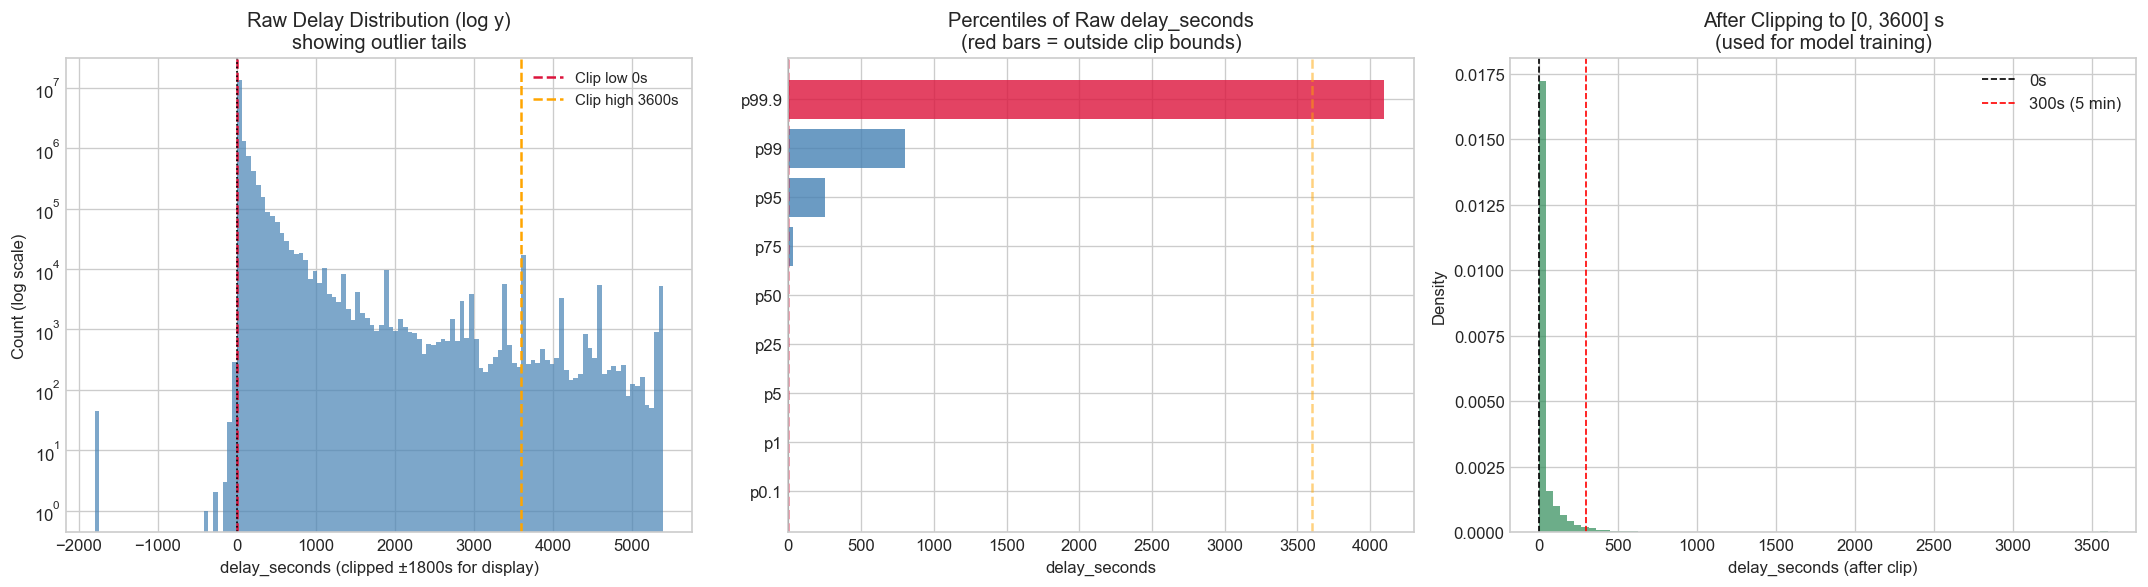

In [7]:
# Load all transit shards for raw outlier inspection
_shards = sorted(PARQUET_DIR.glob("transit_updates*.parquet"))
raw = pd.concat(
    [pd.read_parquet(p, columns=["delay_seconds", "schedule_relationship"]) for p in _shards],
    ignore_index=True,
)
raw = raw[
    (raw["schedule_relationship"] != "CANCELED") & raw["delay_seconds"].notna()
].copy()
raw["delay_seconds"] = raw["delay_seconds"].astype(float)

print(f"Rows analysed (non-canceled, non-null delay): {len(raw):,}")
print(f"\nRaw delay_seconds statistics:")
desc = raw["delay_seconds"].describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
for k, v in desc.items():
    print(f"  {k:8s}: {v:>12,.1f} s")

# Count extreme outliers
CLIP_LOW, CLIP_HIGH = 0, 3600
n_below = (raw["delay_seconds"] < CLIP_LOW).sum()
n_above = (raw["delay_seconds"] > CLIP_HIGH).sum()
pct_extreme = (n_below + n_above) / len(raw) * 100
print(f"\nOutliers outside [{CLIP_LOW}, {CLIP_HIGH}] s:")
print(f"  Below {CLIP_LOW}s : {n_below:,}")
print(f"  Above {CLIP_HIGH}s : {n_above:,}")
print(f"  Total extreme  : {n_below + n_above:,}  ({pct_extreme:.3f}%)")
print(f"\nModel training clips to [{CLIP_LOW}, {CLIP_HIGH}] s — losing only {pct_extreme:.2f}% of rows.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Full raw distribution (log y)
ax = axes[0]
ax.hist(raw["delay_seconds"].clip(-1800, 5400), bins=120,
        color="steelblue", alpha=0.7, log=True)
ax.axvline(CLIP_LOW, color="crimson", lw=1.5, ls="--", label=f"Clip low {CLIP_LOW}s")
ax.axvline(CLIP_HIGH, color="orange", lw=1.5, ls="--", label=f"Clip high {CLIP_HIGH}s")
ax.axvline(0, color="black", lw=1, ls=":")
ax.set_xlabel("delay_seconds (clipped ±1800s for display)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Raw Delay Distribution (log y)\nshowing outlier tails")
ax.legend(fontsize=9)

# (b) Percentile plot to reveal outlier magnitude
ax = axes[1]
sample = raw["delay_seconds"].sort_values().values
pcts = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
vals = [raw["delay_seconds"].quantile(p/100) for p in pcts]
colors = ["crimson" if (v < CLIP_LOW or v > CLIP_HIGH) else "steelblue" for v in vals]
ax.barh([f"p{p}" for p in pcts], vals, color=colors, alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.axvline(CLIP_LOW, color="crimson", lw=1.5, ls="--", alpha=0.5)
ax.axvline(CLIP_HIGH, color="orange", lw=1.5, ls="--", alpha=0.5)
ax.set_xlabel("delay_seconds")
ax.set_title("Percentiles of Raw delay_seconds\n(red bars = outside clip bounds)")

# (c) After-clip distribution
ax = axes[2]
clipped = raw["delay_seconds"].clip(CLIP_LOW, CLIP_HIGH)
ax.hist(clipped, bins=80, color="seagreen", alpha=0.7, density=True)
ax.axvline(0, color="black", lw=1, ls="--", label="0s")
ax.axvline(300, color="red", lw=1, ls="--", label="300s (5 min)")
ax.set_xlabel("delay_seconds (after clip)")
ax.set_ylabel("Density")
ax.set_title(f"After Clipping to [{CLIP_LOW}, {CLIP_HIGH}] s\n(used for model training)")
ax.legend()

plt.tight_layout()
plt.show()


## 3. Delay by Line Group

Rows loaded: 884,736  |  Line groups: ['T1', 'T2', 'T4', 'T8', 'T9']


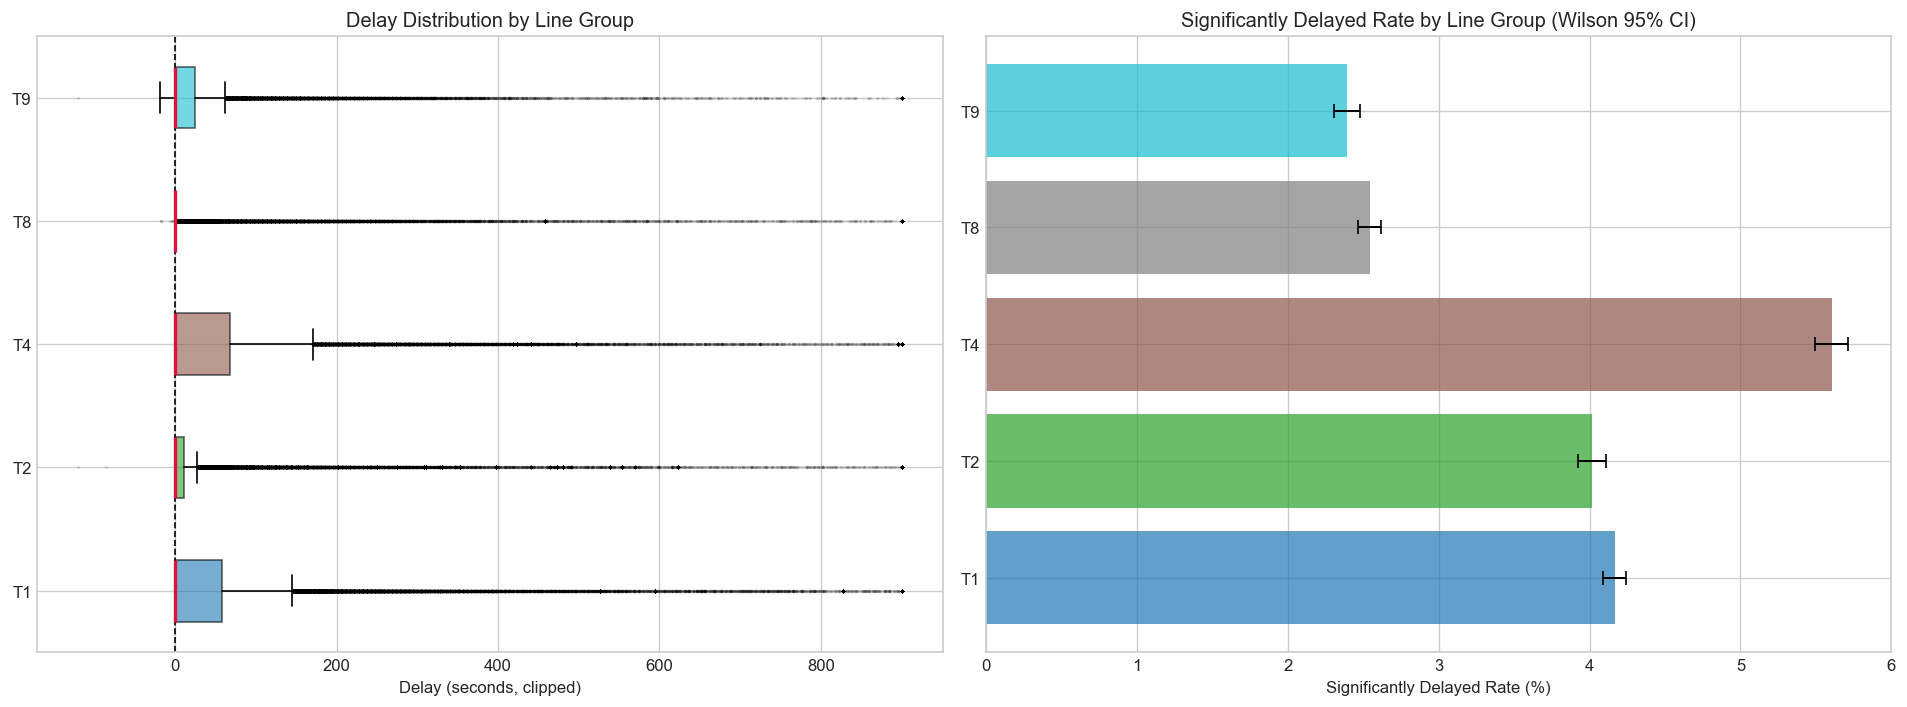


Summary table by line group:
line_group  count  median_delay  mean_delay  pct_significantly_delayed
        T1 259937           0.0        64.3                       4.17
        T2 166776           0.0        57.7                       4.01
        T4 169306           0.0        82.0                       5.60
        T8 169057           0.0        46.6                       2.54
        T9 119660           0.0        46.0                       2.39


In [5]:
from scipy import stats as sp_stats

# ── Load data: use training_dataset if built, else derive from raw transit ──
_td_path = PARQUET_DIR / 'training_dataset.parquet'

if _td_path.exists():
    td = pd.read_parquet(_td_path, columns=['line_group', 'delay_seconds', 'is_significantly_delayed'])
    td['delay_seconds'] = td['delay_seconds'].astype(float)
else:
    print('training_dataset.parquet not found — deriving line_group from raw transit_updates.parquet')
    import duckdb, re
    con = duckdb.connect()
    raw = con.execute(
        f"""SELECT route_id, delay_seconds
            FROM read_parquet('{PARQUET_DIR / 'transit_updates.parquet'}')
            WHERE schedule_relationship != 'CANCELED'
              AND delay_seconds IS NOT NULL
            USING SAMPLE 500000 ROWS"""
    ).df()
    con.close()

    _HEAVY_RAIL = ['T1', 'T2', 'T4', 'T8', 'T9']
    _LR_PREFIX  = {'APS': 'L1', 'SHL': 'L2', 'NLR': 'L3', 'PLR': 'L4', 'CCN': 'L2'}

    def _derive_line_group(route_id: str) -> str:
        for line in _HEAVY_RAIL:
            if route_id.startswith(line + '_') or route_id == line:
                return line
        prefix = route_id.split('_')[0] if '_' in route_id else route_id[:3]
        return _LR_PREFIX.get(prefix, 'Other')

    raw['delay_seconds'] = raw['delay_seconds'].astype(float)
    raw['line_group']    = raw['route_id'].apply(_derive_line_group)
    raw['is_significantly_delayed'] = (raw['delay_seconds'] > 300).astype('int8')
    td = raw[['line_group', 'delay_seconds', 'is_significantly_delayed']]

print(f'Rows loaded: {len(td):,}  |  Line groups: {sorted(td["line_group"].unique())}')
td['delay_clipped'] = td['delay_seconds'].clip(-120, 900)

# Sort by median for plots
order = (
    td.groupby('line_group')['delay_clipped']
    .median()
    .sort_values()
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (left) Horizontal boxplot
ax = axes[0]
data_by_group = [td.loc[td['line_group'] == g, 'delay_clipped'].dropna().values for g in order]
bp = ax.boxplot(
    data_by_group,
    vert=False,
    labels=order,
    patch_artist=True,
    flierprops=dict(marker='.', alpha=0.05, markersize=2),
    medianprops=dict(color='crimson', lw=2),
)
colors = plt.cm.tab10(np.linspace(0, 1, len(order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Delay (seconds, clipped)')
ax.set_title('Delay Distribution by Line Group')

# (right) Bar chart of significantly delayed rate with Wilson CI
ax = axes[1]
summary = []
for g in order:
    grp = td[td['line_group'] == g]['is_significantly_delayed'].dropna().astype(int)
    n = len(grp)
    p = grp.mean() if n > 0 else 0.0
    z = 1.96
    denom     = 1 + z**2 / n if n > 0 else 1
    p_tilde   = (p + z**2 / (2 * n)) / denom if n > 0 else 0
    margin    = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom if n > 0 else 0
    summary.append({'line_group': g, 'n': n, 'rate': p * 100,
                    'lo': max(0, p_tilde - margin) * 100, 'hi': (p_tilde + margin) * 100})

summary_df = pd.DataFrame(summary)
y_pos = np.arange(len(order))
ax.barh(y_pos, summary_df['rate'],
        xerr=[summary_df['rate'] - summary_df['lo'], summary_df['hi'] - summary_df['rate']],
        color=colors, alpha=0.7, capsize=4, error_kw=dict(elinewidth=1.2))
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel('Significantly Delayed Rate (%)')
ax.set_title('Significantly Delayed Rate by Line Group (Wilson 95% CI)')

plt.tight_layout()
plt.show()

# Summary table
summary_tbl = (
    td.groupby('line_group')
    .agg(
        count=('delay_seconds', 'count'),
        median_delay=('delay_seconds', 'median'),
        mean_delay=('delay_seconds', 'mean'),
        pct_significantly_delayed=('is_significantly_delayed', lambda x: x.mean() * 100),
    )
    .reset_index()
    .sort_values('median_delay')
)
summary_tbl['median_delay'] = summary_tbl['median_delay'].round(1)
summary_tbl['mean_delay']   = summary_tbl['mean_delay'].round(1)
summary_tbl['pct_significantly_delayed'] = summary_tbl['pct_significantly_delayed'].round(2)
print('\nSummary table by line group:')
print(summary_tbl.to_string(index=False))


## 4. Temporal Patterns

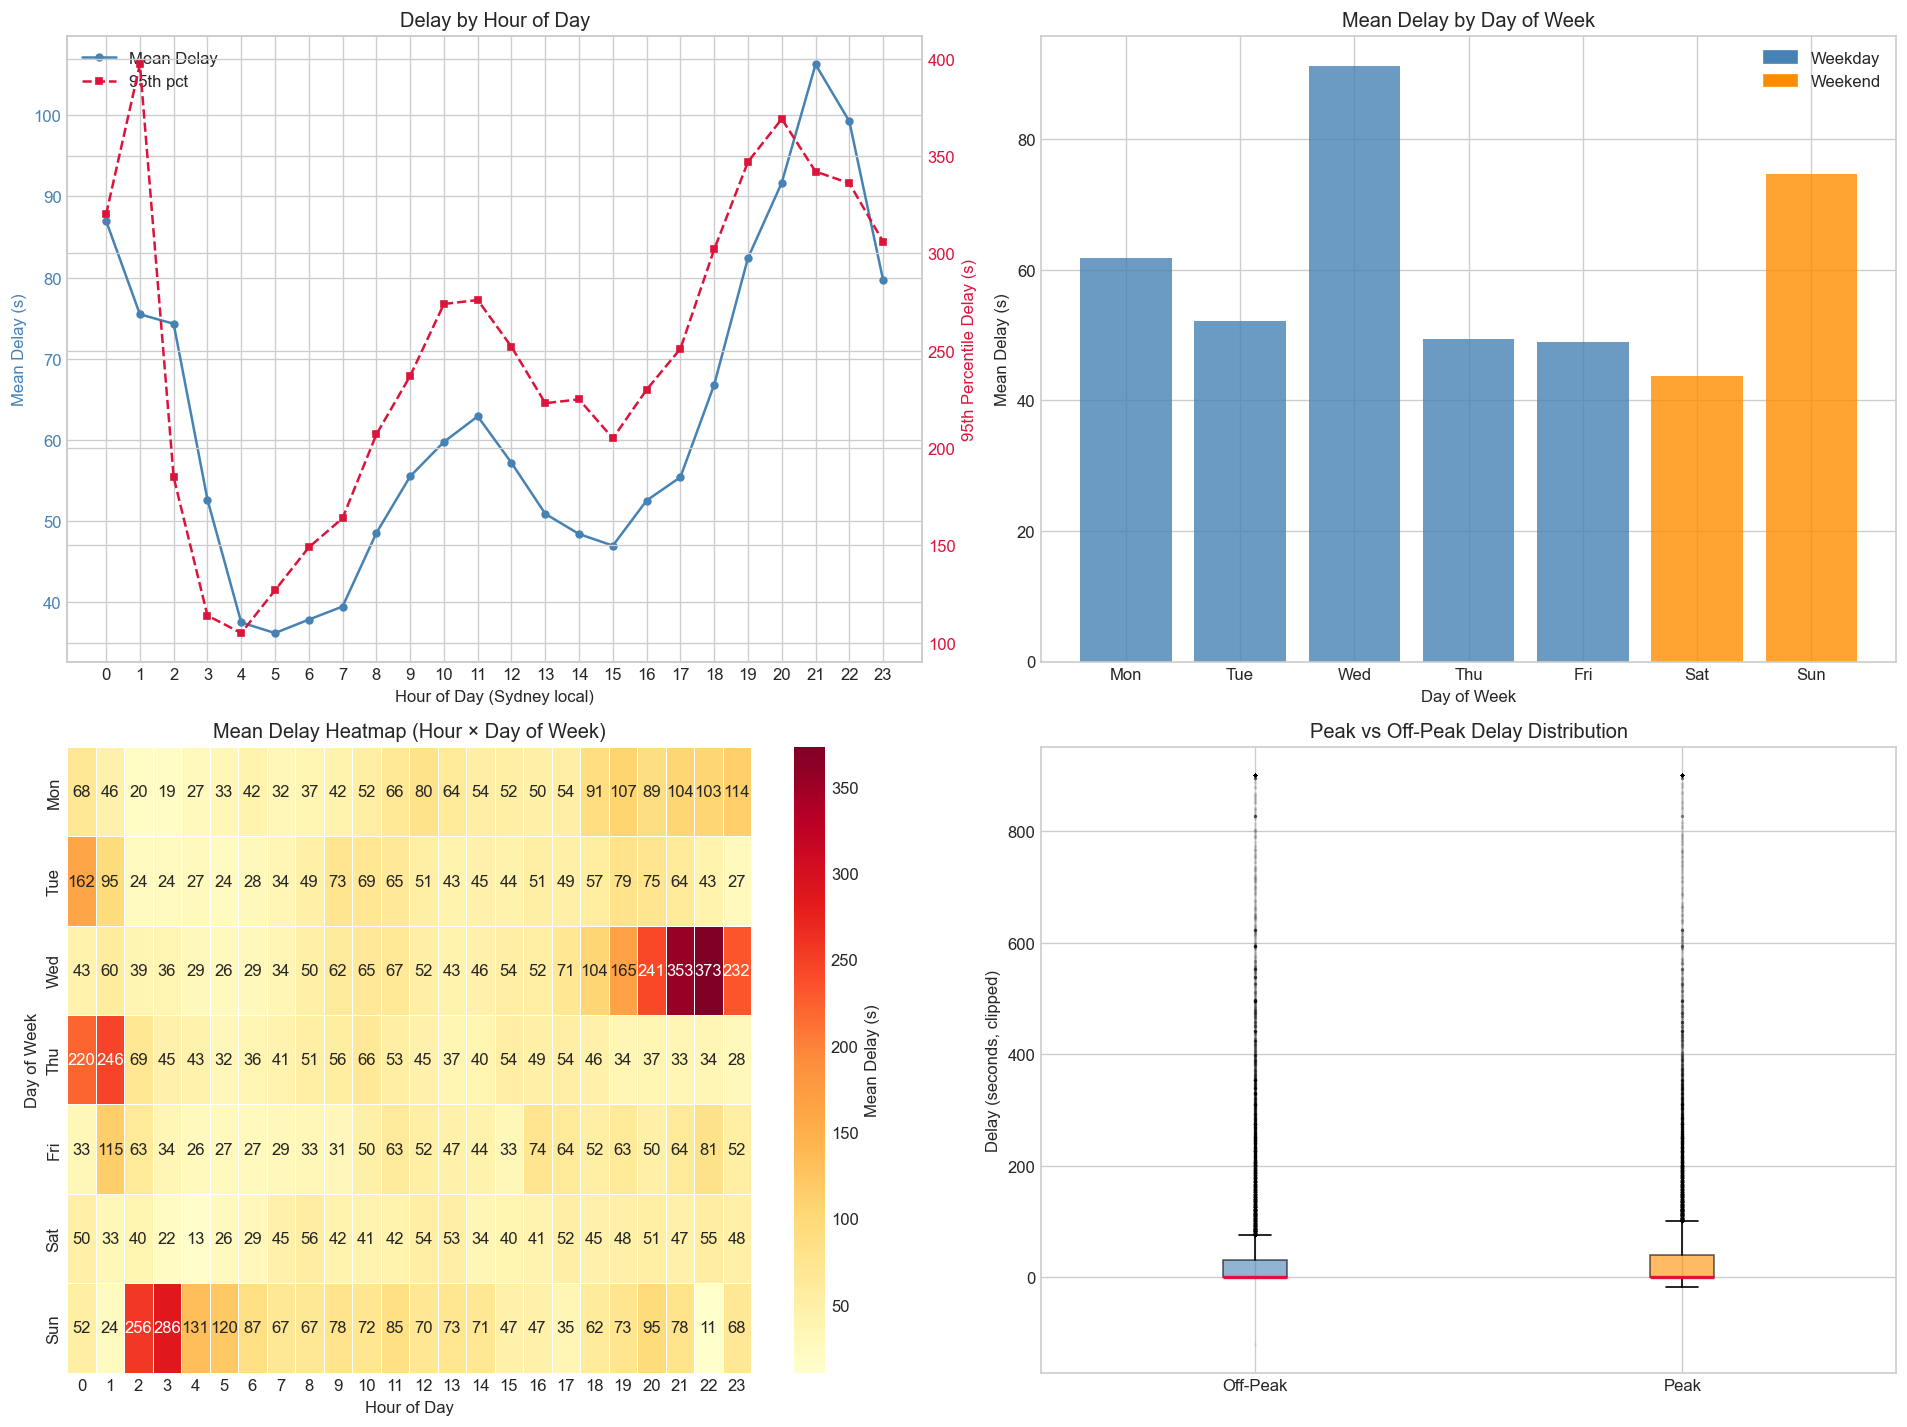

In [6]:
td = pd.read_parquet(
    PARQUET_DIR / "training_dataset.parquet",
    columns=["timestamp", "delay_seconds", "is_peak_hour", "hour", "day_of_week", "is_weekend"]
)
td["delay_seconds"] = td["delay_seconds"].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (top-left) Mean + 95th pct delay by Sydney local hour
ax1 = axes[0, 0]
hourly = td.groupby("hour")["delay_seconds"].agg(["mean", lambda x: x.quantile(0.95)]).reset_index()
hourly.columns = ["hour", "mean", "p95"]
color_mean = "steelblue"
color_p95 = "crimson"
ax1.plot(hourly["hour"], hourly["mean"], color=color_mean, marker="o", ms=4, label="Mean Delay")
ax1.set_xlabel("Hour of Day (Sydney local)")
ax1.set_ylabel("Mean Delay (s)", color=color_mean)
ax1.tick_params(axis="y", labelcolor=color_mean)
ax2_twin = ax1.twinx()
ax2_twin.plot(hourly["hour"], hourly["p95"], color=color_p95, marker="s", ms=4, ls="--", label="95th pct")
ax2_twin.set_ylabel("95th Percentile Delay (s)", color=color_p95)
ax2_twin.tick_params(axis="y", labelcolor=color_p95)
ax1.set_title("Delay by Hour of Day")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_xticks(range(0, 24))

# (top-right) Mean delay by day_of_week
ax = axes[0, 1]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = td.groupby("day_of_week")["delay_seconds"].mean().reindex(range(7))
colors_dow = ["steelblue" if i < 5 else "darkorange" for i in range(7)]
ax.bar(range(7), daily.values, color=colors_dow, alpha=0.8)
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean Delay (s)")
ax.set_title("Mean Delay by Day of Week")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Weekday"), Patch(color="darkorange", label="Weekend")])

# (bottom-left) Heatmap mean delay by hour x day_of_week
ax = axes[1, 0]
pivot = td.groupby(["day_of_week", "hour"])["delay_seconds"].mean().unstack(level=1)
pivot.index = [day_labels[i] for i in pivot.index]
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.3, cbar_kws={"label": "Mean Delay (s)"}
)
ax.set_title("Mean Delay Heatmap (Hour × Day of Week)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

# (bottom-right) Peak vs off-peak box plot
ax = axes[1, 1]
peak_data = td[td["is_peak_hour"] == 1]["delay_seconds"].clip(-120, 900).dropna()
offpeak_data = td[td["is_peak_hour"] == 0]["delay_seconds"].clip(-120, 900).dropna()
bp = ax.boxplot(
    [offpeak_data.sample(min(50000, len(offpeak_data)), random_state=42).values,
     peak_data.sample(min(50000, len(peak_data)), random_state=42).values],
    labels=["Off-Peak", "Peak"],
    patch_artist=True,
    flierprops=dict(marker=".", alpha=0.05, markersize=2),
    medianprops=dict(color="crimson", lw=2),
)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("darkorange")
bp["boxes"][1].set_alpha(0.6)
ax.set_ylabel("Delay (seconds, clipped)")
ax.set_title("Peak vs Off-Peak Delay Distribution")

plt.tight_layout()
plt.show()

## 5. Weather vs Delay

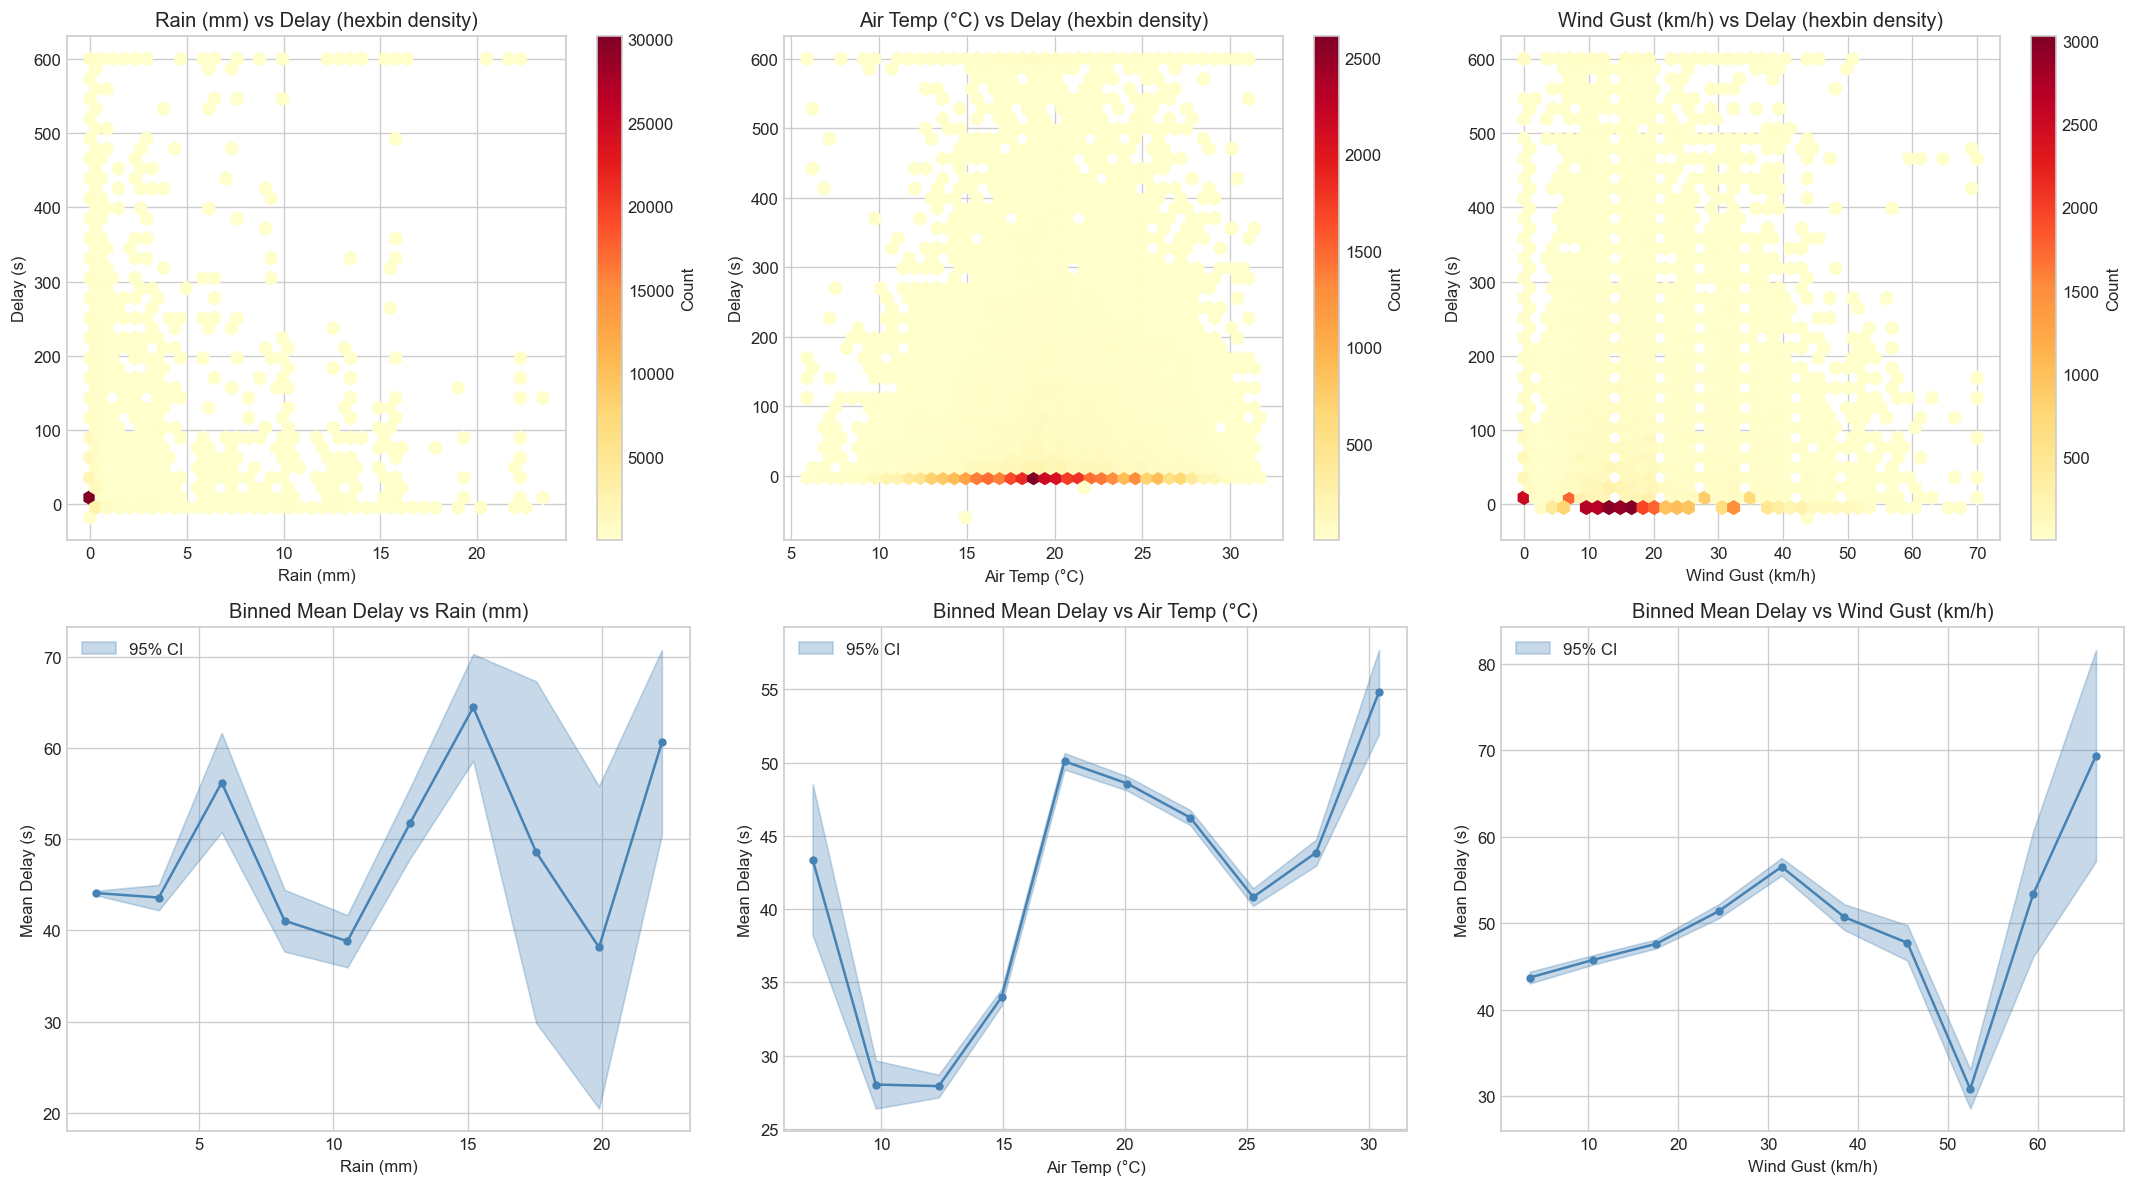


Correlation table: weather variables vs delay_seconds
Variable                Pearson r    Pearson p   Spearman r   Spearman p
----------------------------------------------------------------------
Rain (mm)                  0.0178   7.1653e-05      -0.0009   8.4077e-01
Air Temp (°C)              0.0244   4.9267e-08       0.0664   4.8751e-50
Wind Gust (km/h)           0.0221   7.4030e-07       0.0365   3.5053e-16


In [22]:
from scipy import stats as sp_stats

td = pd.read_parquet(
    PARQUET_DIR / "training_dataset.parquet",
    columns=["delay_seconds", "air_temp_c", "rain_trace_mm", "wind_gust_kmh"]
)
td["delay_seconds"] = td["delay_seconds"].astype(float).clip(-60, 600)
td = td.dropna(subset=["air_temp_c", "rain_trace_mm", "wind_gust_kmh"], how="all")

weather_vars = [
    ("rain_trace_mm", "Rain (mm)"),
    ("air_temp_c", "Air Temp (°C)"),
    ("wind_gust_kmh", "Wind Gust (km/h)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (col, label) in enumerate(weather_vars):
    sub = td[[col, "delay_seconds"]].dropna()
    sample = sub.sample(min(50000, len(sub)), random_state=42)

    # Top row: hexbin scatter
    ax = axes[0, col_idx]
    hb = ax.hexbin(sample[col], sample["delay_seconds"], gridsize=40, cmap="YlOrRd", mincnt=1)
    plt.colorbar(hb, ax=ax, label="Count")
    ax.set_xlabel(label)
    ax.set_ylabel("Delay (s)")
    ax.set_title(f"{label} vs Delay (hexbin density)")

    # Bottom row: binned mean delay with 95% CI
    ax = axes[1, col_idx]
    sub_valid = sub.copy()
    sub_valid["bin"] = pd.cut(sub_valid[col], bins=10)
    binned = sub_valid.groupby("bin")["delay_seconds"].agg(["mean", "std", "count"]).reset_index()
    binned["ci"] = 1.96 * binned["std"] / np.sqrt(binned["count"])
    bin_centers = binned["bin"].apply(lambda x: x.mid).astype(float)
    ax.plot(bin_centers, binned["mean"], color="steelblue", marker="o", ms=4)
    ax.fill_between(
        bin_centers,
        binned["mean"] - binned["ci"],
        binned["mean"] + binned["ci"],
        alpha=0.3, color="steelblue", label="95% CI"
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Mean Delay (s)")
    ax.set_title(f"Binned Mean Delay vs {label}")
    ax.legend()

plt.tight_layout()
plt.show()

print("\nCorrelation table: weather variables vs delay_seconds")
print(f"{'Variable':<20} {'Pearson r':>12} {'Pearson p':>12} {'Spearman r':>12} {'Spearman p':>12}")
print("-" * 70)
for col, label in weather_vars:
    sub = td[[col, "delay_seconds"]].dropna()
    if len(sub) < 10:
        print(f"{label:<20}  insufficient data")
        continue
    samp = sub.sample(min(50000, len(sub)), random_state=42)
    pr, pp = sp_stats.pearsonr(samp[col], samp["delay_seconds"])
    sr, sp = sp_stats.spearmanr(samp[col], samp["delay_seconds"])
    print(f"{label:<20} {pr:>12.4f} {pp:>12.4e} {sr:>12.4f} {sp:>12.4e}")

## 5.1 Weather Collection Window

The model trained on ~21 days of Autumn 2026 data in mild conditions. Understanding how narrow this weather envelope is explains why weather features provide weak signal — and why retraining on a full seasonal cycle will likely produce much stronger models.

Collection period: 2026-03-31 → 2026-04-21

Weather statistics (all observations):
  Air temp    : min=5.9°C  mean=19.6°C  max=31.7°C  std=4.2°C
  Rain        : min=0.0mm  mean=0.4mm  max=23.4mm  std=2.1mm
  Wind gust   : min=0.0km/h  mean=16.8km/h  max=70.0km/h  std=10.9km/h


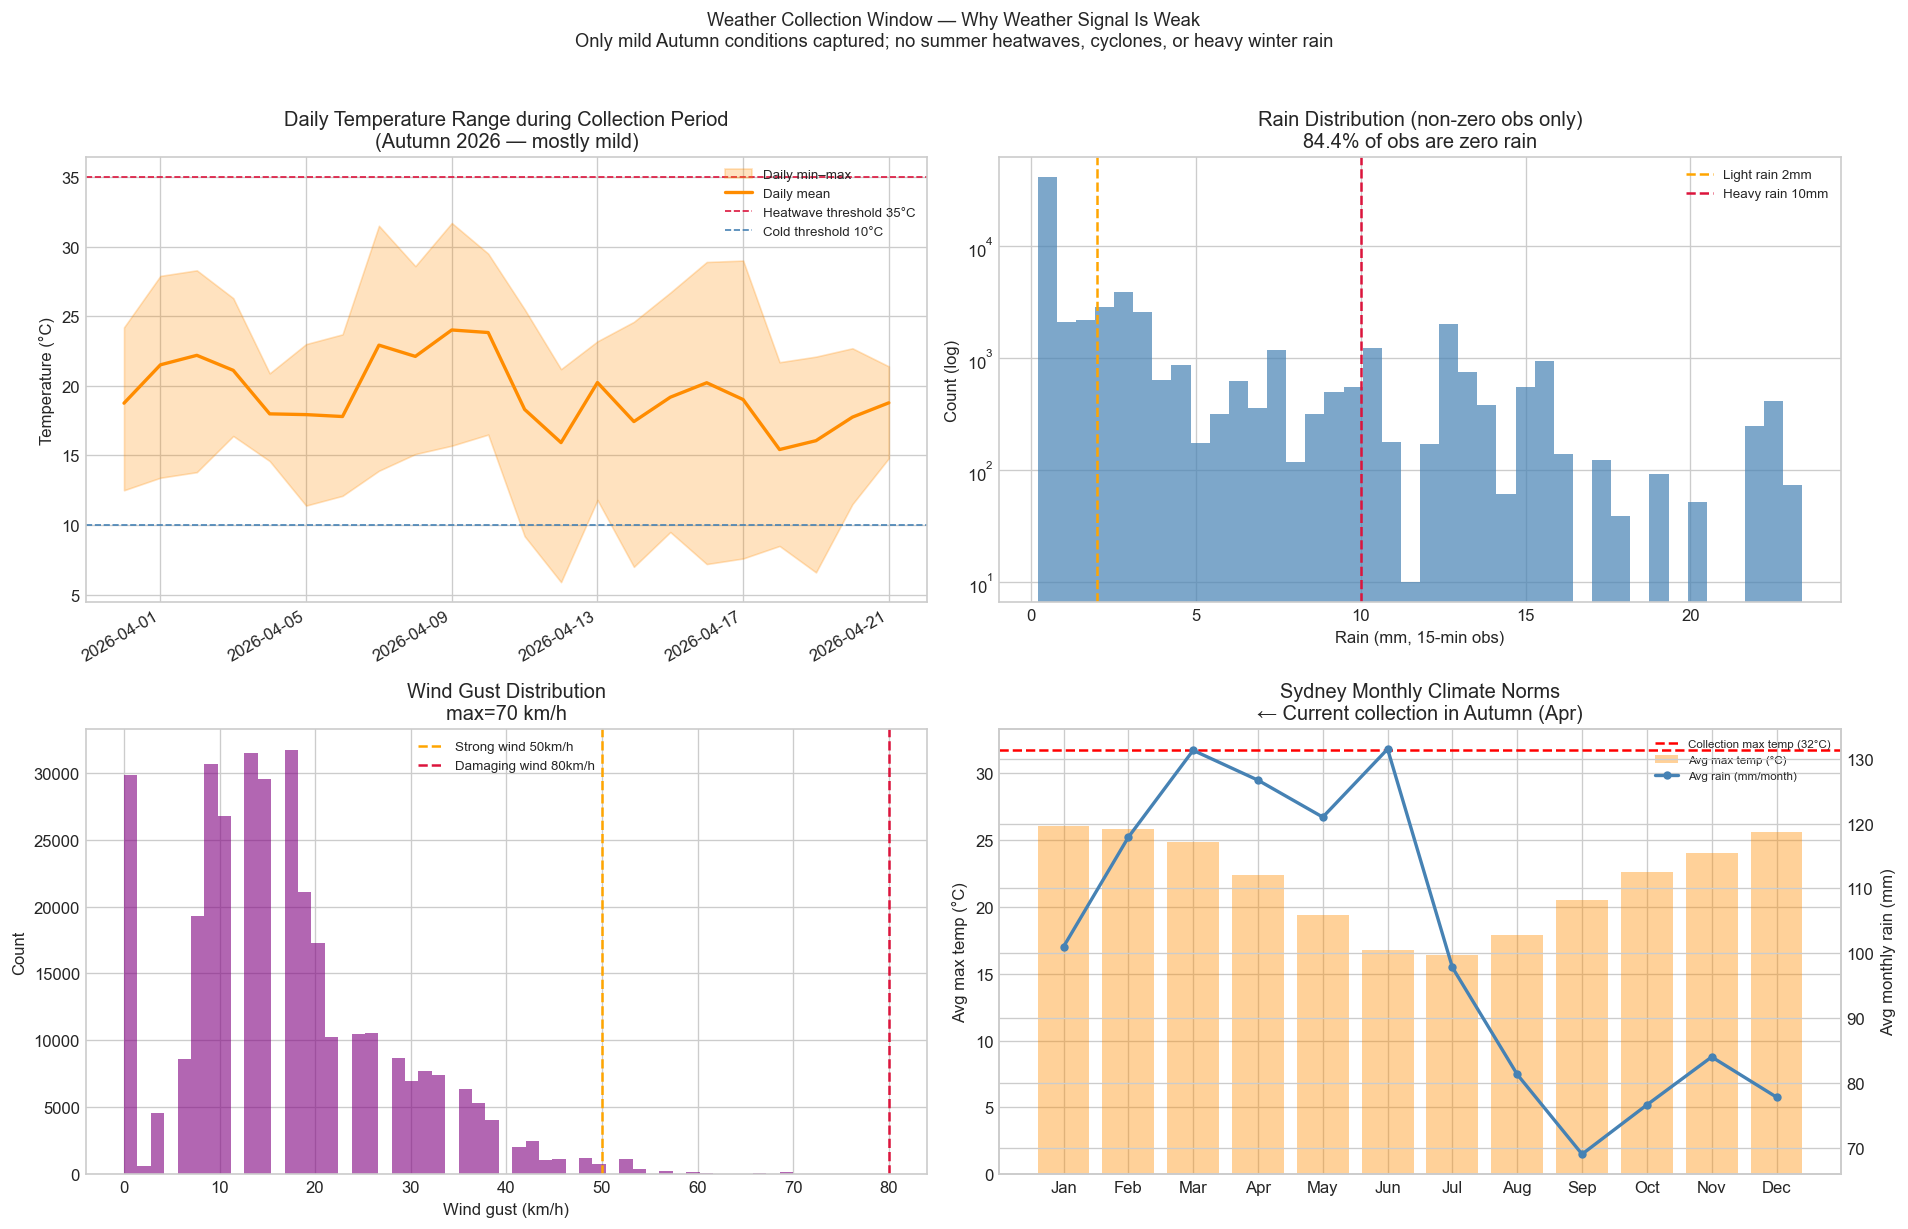


⚠️  Model training note:
  Temperature range captured: 5.9°C – 31.7°C
  Sydney summer max can exceed 40°C (vs 32°C captured)
  Rain events: only 7464 heavy rain (>10mm) obs in collection period
  Conclusion: retraining after 6-12 months of data will show much stronger weather correlation.


In [23]:
# Load training dataset weather columns (must exist)
_td_path = PARQUET_DIR / "training_dataset.parquet"
if not _td_path.exists():
    print("⚠️  training_dataset.parquet not found — skipping weather coverage plot.")
    print("   Run: uv run python -m app.ml.train --skip-terminus")
else:
    wd = pd.read_parquet(_td_path, columns=["timestamp", "air_temp_c", "rain_trace_mm", "wind_gust_kmh"])
    wd["timestamp"] = pd.to_datetime(wd["timestamp"], utc=True)
    wd["date"] = wd["timestamp"].dt.date

    # Deduplicate by station read (many rows share same obs)
    obs = wd.dropna(subset=["air_temp_c"]).drop_duplicates(subset=["timestamp", "air_temp_c"])

    print(f"Collection period: {wd['timestamp'].min().date()} → {wd['timestamp'].max().date()}")
    print(f"\nWeather statistics (all observations):")
    for col, label, unit in [("air_temp_c","Air temp","°C"),("rain_trace_mm","Rain","mm"),("wind_gust_kmh","Wind gust","km/h")]:
        s = obs[col].dropna()
        print(f"  {label:12s}: min={s.min():.1f}{unit}  mean={s.mean():.1f}{unit}  max={s.max():.1f}{unit}  std={s.std():.1f}{unit}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # (top-left) Daily temperature range
    ax = axes[0, 0]
    daily = obs.groupby("date")["air_temp_c"].agg(["min", "max", "mean"]).reset_index()
    ax.fill_between(daily["date"], daily["min"], daily["max"], alpha=0.25, color="darkorange", label="Daily min–max")
    ax.plot(daily["date"], daily["mean"], color="darkorange", lw=2, label="Daily mean")
    ax.axhline(35, color="crimson", ls="--", lw=1, label="Heatwave threshold 35°C")
    ax.axhline(10, color="steelblue", ls="--", lw=1, label="Cold threshold 10°C")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title("Daily Temperature Range during Collection Period\n(Autumn 2026 — mostly mild)")
    ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # (top-right) Rain distribution
    ax = axes[0, 1]
    rain = obs["rain_trace_mm"].dropna()
    ax.hist(rain[rain > 0], bins=40, color="steelblue", alpha=0.7, log=True)
    ax.axvline(2, color="orange", ls="--", lw=1.5, label="Light rain 2mm")
    ax.axvline(10, color="crimson", ls="--", lw=1.5, label="Heavy rain 10mm")
    pct_zero = (rain == 0).mean() * 100
    ax.set_xlabel("Rain (mm, 15-min obs)")
    ax.set_ylabel("Count (log)")
    ax.set_title(f"Rain Distribution (non-zero obs only)\n{pct_zero:.1f}% of obs are zero rain")
    ax.legend(fontsize=8)

    # (bottom-left) Wind gust distribution
    ax = axes[1, 0]
    wind = obs["wind_gust_kmh"].dropna()
    ax.hist(wind, bins=50, color="purple", alpha=0.6)
    ax.axvline(50, color="orange", ls="--", lw=1.5, label="Strong wind 50km/h")
    ax.axvline(80, color="crimson", ls="--", lw=1.5, label="Damaging wind 80km/h")
    ax.set_xlabel("Wind gust (km/h)")
    ax.set_ylabel("Count")
    ax.set_title(f"Wind Gust Distribution\nmax={wind.max():.0f} km/h")
    ax.legend(fontsize=8)

    # (bottom-right) Weather envelope vs annual Sydney norms
    ax = axes[1, 1]
    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    # Sydney average monthly max temps (BOM normals)
    sydney_avg_max = [26.0, 25.8, 24.8, 22.4, 19.4, 16.8, 16.4, 17.9, 20.5, 22.6, 24.0, 25.6]
    sydney_avg_rain = [101.0, 117.9, 131.3, 126.7, 121.0, 131.5, 97.8, 81.3, 69.0, 76.6, 84.0, 77.8]
    ax2 = ax.twinx()
    x = range(12)
    bars = ax.bar(x, sydney_avg_max, color="darkorange", alpha=0.4, label="Avg max temp (°C)")
    ax2.plot(x, sydney_avg_rain, "steelblue", lw=2, marker="o", markersize=4, label="Avg rain (mm/month)")
    ax.axhline(obs["air_temp_c"].max(), color="red", ls="--", lw=1.5, 
               label=f"Collection max temp ({obs['air_temp_c'].max():.0f}°C)")
    ax.set_xticks(x)
    ax.set_xticklabels(months)
    ax.set_ylabel("Avg max temp (°C)")
    ax2.set_ylabel("Avg monthly rain (mm)")
    ax.set_title("Sydney Monthly Climate Norms\n← Current collection in Autumn (Apr)")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

    plt.suptitle("Weather Collection Window — Why Weather Signal Is Weak\n"
                 "Only mild Autumn conditions captured; no summer heatwaves, cyclones, or heavy winter rain",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n⚠️  Model training note:")
    print(f"  Temperature range captured: {obs['air_temp_c'].min():.1f}°C – {obs['air_temp_c'].max():.1f}°C")
    print(f"  Sydney summer max can exceed 40°C (vs {obs['air_temp_c'].max():.0f}°C captured)")
    print(f"  Rain events: only {(rain > 10).sum()} heavy rain (>10mm) obs in collection period")
    print(f"  Conclusion: retraining after 6-12 months of data will show much stronger weather correlation.")


## 6. Incident Impact

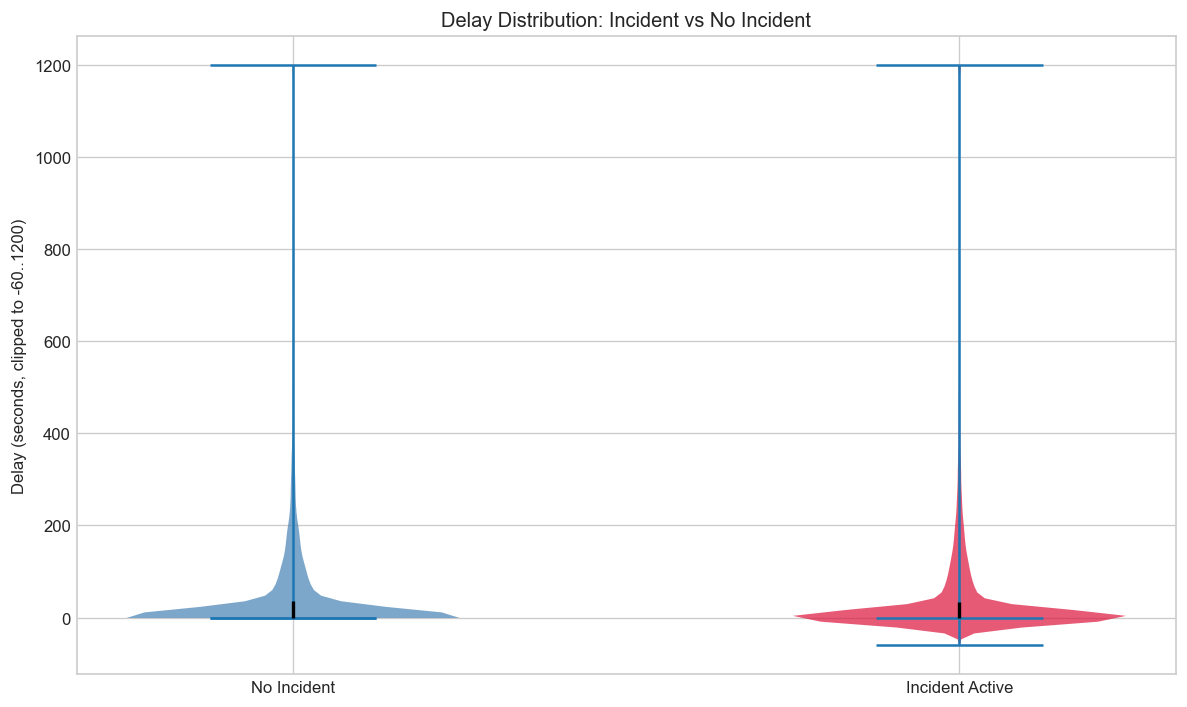


Group statistics:

  No Incident (is_incident_active=0):
    n: 15,056
    mean: 45.74
    median: 0.00
    p75: 36.00
    p95: 228.25
    pct_sig_delayed: 3.28

  Incident Active (is_incident_active=1):
    n: 869,680
    mean: 49.84
    median: 0.00
    p75: 33.00
    p95: 250.00
    pct_sig_delayed: 3.87

Mann-Whitney U test:
  U statistic: 383674691.00
  p-value:     2.6781e-05
  Result:      Significant difference (alpha=0.05)


In [24]:
from scipy import stats as sp_stats

td = pd.read_parquet(
    PARQUET_DIR / "training_dataset.parquet",
    columns=["delay_seconds", "is_incident_active"]
)
td["delay_seconds"] = td["delay_seconds"].astype(float).clip(-60, 1200)
td = td.dropna(subset=["delay_seconds", "is_incident_active"])

no_incident = td[td["is_incident_active"] == 0]["delay_seconds"].dropna()
incident = td[td["is_incident_active"] == 1]["delay_seconds"].dropna()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
violin_data = [
    no_incident.sample(min(50000, len(no_incident)), random_state=42).values,
    incident.sample(min(50000, len(incident)), random_state=42).values,
]
parts = ax.violinplot(violin_data, positions=[0, 1], showmedians=True)
for pc in parts["bodies"]:
    pc.set_alpha(0.7)
parts["bodies"][0].set_facecolor("steelblue")
parts["bodies"][1].set_facecolor("crimson")

# Add quartile lines manually
for i, grp in enumerate([no_incident, incident]):
    q25, q75 = grp.quantile(0.25), grp.quantile(0.75)
    ax.vlines(i, q25, q75, color="black", lw=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(["No Incident", "Incident Active"])
ax.set_ylabel("Delay (seconds, clipped to -60..1200)")
ax.set_title("Delay Distribution: Incident vs No Incident")

plt.tight_layout()
plt.show()

def group_stats(arr):
    arr = arr.dropna()
    return {
        "n": len(arr),
        "mean": arr.mean(),
        "median": arr.median(),
        "p75": arr.quantile(0.75),
        "p95": arr.quantile(0.95),
        "pct_sig_delayed": ((arr > 300).mean() * 100),
    }

print("\nGroup statistics:")
for label, grp in [("No Incident (is_incident_active=0)", no_incident), ("Incident Active (is_incident_active=1)", incident)]:
    s = group_stats(grp)
    print(f"\n  {label}:")
    for k, v in s.items():
        print(f"    {k}: {v:.2f}" if isinstance(v, float) else f"    {k}: {v:,}")

# Mann-Whitney U test
samp_no = no_incident.sample(min(50000, len(no_incident)), random_state=42)
samp_yes = incident.sample(min(50000, len(incident)), random_state=42)
u_stat, p_val = sp_stats.mannwhitneyu(samp_no, samp_yes, alternative="two-sided")
print(f"\nMann-Whitney U test:")
print(f"  U statistic: {u_stat:.2f}")
print(f"  p-value:     {p_val:.4e}")
print(f"  Result:      {'Significant difference' if p_val < 0.05 else 'No significant difference'} (alpha=0.05)")

## 7. Schedule Relationship & Ghost Trains

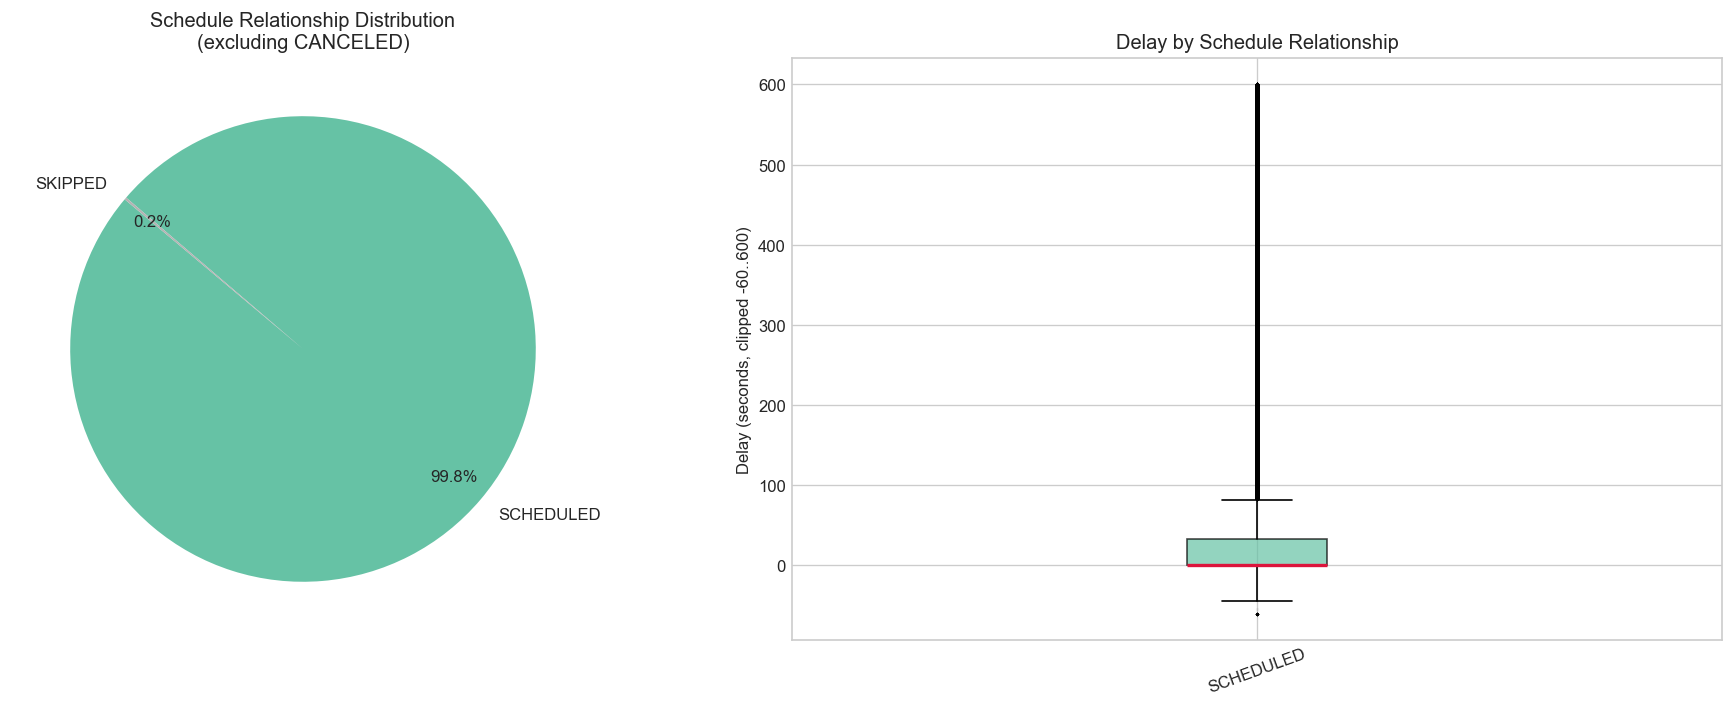


Counts and median delay by schedule_relationship (excl. CANCELED):
Relationship                Count   Median Delay (s)
-------------------------------------------------------
SCHEDULED              17,087,940                0.0


In [25]:
_shards = sorted(PARQUET_DIR.glob("transit_updates*.parquet"))
tu = pd.concat(
    [pd.read_parquet(p, columns=["schedule_relationship", "delay_seconds", "timestamp"])
     for p in _shards],
    ignore_index=True,
)
tu["delay_seconds"] = tu["delay_seconds"].astype(float)

# Exclude CANCELED for pie and box plot
tu_no_canceled = tu[tu["schedule_relationship"] != "CANCELED"].copy()
sr_counts = tu_no_canceled["schedule_relationship"].value_counts(dropna=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (left) Pie chart
ax = axes[0]
wedge_labels = [str(k) if pd.notna(k) else "None" for k in sr_counts.index]
wedge_colors = plt.cm.Set2(np.linspace(0, 1, len(sr_counts)))
ax.pie(
    sr_counts.values,
    labels=wedge_labels,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.85,
)
ax.set_title("Schedule Relationship Distribution\n(excluding CANCELED)")

# (right) Box plot of delay by schedule_relationship
ax = axes[1]
tu_box = tu_no_canceled.dropna(subset=["delay_seconds"]).copy()
tu_box["delay_clipped"] = tu_box["delay_seconds"].clip(-60, 600)
sr_order = (
    tu_box.groupby("schedule_relationship")["delay_clipped"]
    .median()
    .sort_values()
    .index.tolist()
)
box_data = [
    tu_box[tu_box["schedule_relationship"] == s]["delay_clipped"].dropna().values
    for s in sr_order
]
bp = ax.boxplot(
    box_data,
    labels=sr_order,
    patch_artist=True,
    flierprops=dict(marker=".", alpha=0.05, markersize=2),
    medianprops=dict(color="crimson", lw=2),
)
box_colors = plt.cm.Set2(np.linspace(0, 1, len(sr_order)))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Delay (seconds, clipped -60..600)")
ax.set_title("Delay by Schedule Relationship")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("\nCounts and median delay by schedule_relationship (excl. CANCELED):")
print(f"{'Relationship':<20} {'Count':>12} {'Median Delay (s)':>18}")
print("-" * 55)
for s in sr_order:
    grp = tu_box[tu_box["schedule_relationship"] == s]["delay_clipped"]
    print(f"{str(s):<20} {len(grp):>12,} {grp.median():>18.1f}")

## 8. Vehicle Occupancy

Occupancy data coverage: 0.00% (0 of 884,736 rows)


ValueError: Dimensions of labels and X must be compatible

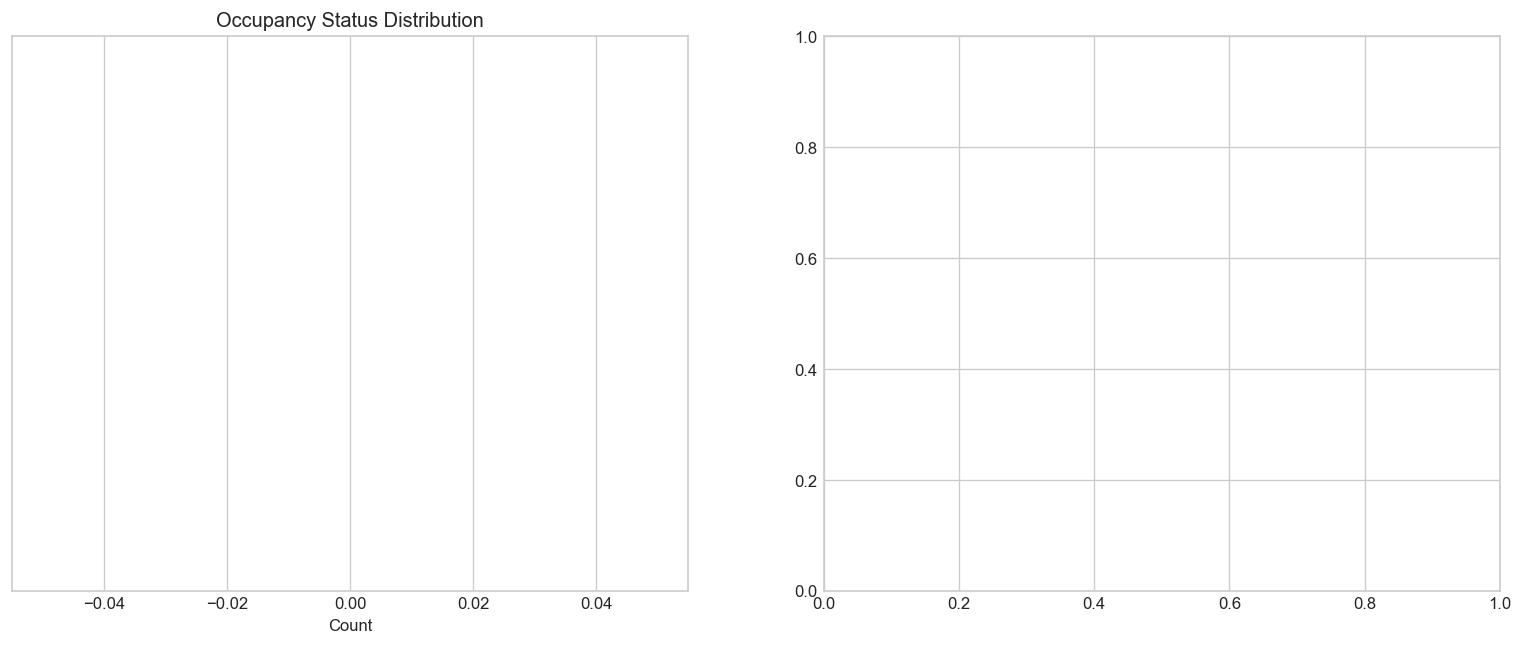

In [26]:
td = pd.read_parquet(
    PARQUET_DIR / "training_dataset.parquet",
    columns=["occupancy_status", "occupancy_encoded", "delay_seconds"]
)
td["delay_seconds"] = td["delay_seconds"].astype(float)

total_rows = len(td)
has_occupancy = td["occupancy_status"].notna()
pct_coverage = has_occupancy.mean() * 100
print(f"Occupancy data coverage: {pct_coverage:.2f}% ({has_occupancy.sum():,} of {total_rows:,} rows)")

td_occ = td[has_occupancy].copy()

# Occupancy name mapping
occ_map = {
    0: "EMPTY",
    1: "MANY_SEATS",
    2: "FEW_SEATS",
    3: "STANDING_ROOM",
    4: "CRUSHED",
    5: "FULL",
    6: "NOT_ACCEPTING",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (left) Horizontal bar chart of occupancy_status value counts
ax = axes[0]
occ_counts = td_occ["occupancy_status"].value_counts().sort_values(ascending=True)
bar_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(occ_counts)))
ax.barh(range(len(occ_counts)), occ_counts.values, color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(occ_counts)))
ax.set_yticklabels(occ_counts.index.tolist())
ax.set_xlabel("Count")
ax.set_title("Occupancy Status Distribution")
for i, v in enumerate(occ_counts.values):
    ax.text(v * 1.01, i, f"{v:,}", va="center", fontsize=8)

# (right) Box plot of delay by occupancy_encoded
ax = axes[1]
encoded_vals = sorted(td_occ["occupancy_encoded"].dropna().unique().astype(int))
box_data = [
    td_occ[td_occ["occupancy_encoded"] == e]["delay_seconds"].clip(-60, 600).dropna().values
    for e in encoded_vals
]
bp = ax.boxplot(
    box_data,
    labels=[occ_map.get(e, str(e)) for e in encoded_vals],
    patch_artist=True,
    flierprops=dict(marker=".", alpha=0.05, markersize=2),
    medianprops=dict(color="crimson", lw=2),
)
fill_colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(encoded_vals)))
for patch, color in zip(bp["boxes"], fill_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel("Occupancy Status")
ax.set_ylabel("Delay (seconds, clipped -60..600)")
ax.set_title("Delay by Occupancy Level")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 9. Missing Value Audit

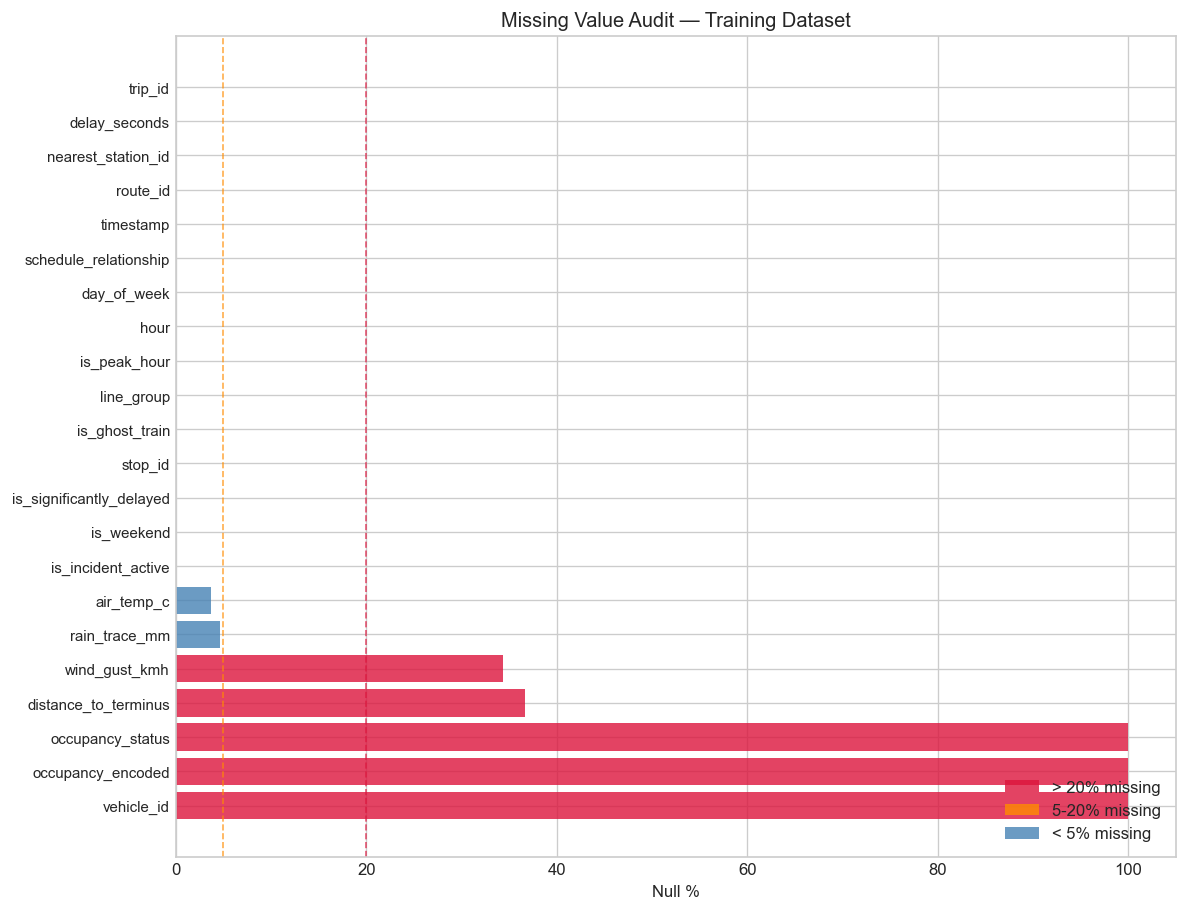


Full null % table (sorted descending):
                  column  null_pct
              vehicle_id   100.000
       occupancy_encoded   100.000
        occupancy_status   100.000
    distance_to_terminus    36.626
           wind_gust_kmh    34.323
           rain_trace_mm     4.651
              air_temp_c     3.738
      is_incident_active     0.000
              is_weekend     0.000
is_significantly_delayed     0.000
                 stop_id     0.000
          is_ghost_train     0.000
              line_group     0.000
            is_peak_hour     0.000
                    hour     0.000
             day_of_week     0.000
   schedule_relationship     0.000
               timestamp     0.000
                route_id     0.000
      nearest_station_id     0.000
           delay_seconds     0.000
                 trip_id     0.000


In [27]:
td = pd.read_parquet(PARQUET_DIR / "training_dataset.parquet")

null_pct = (td.isnull().sum() / len(td) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(null_pct) * 0.35)))
colors = ["crimson" if v > 20 else "darkorange" if v > 5 else "steelblue" for v in null_pct.values]
ax.barh(range(len(null_pct)), null_pct.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(null_pct)))
ax.set_yticklabels(null_pct.index.tolist(), fontsize=9)
ax.set_xlabel("Null %")
ax.set_title("Missing Value Audit — Training Dataset")
ax.axvline(5, color="darkorange", lw=1, ls="--", alpha=0.7, label="5% threshold")
ax.axvline(20, color="crimson", lw=1, ls="--", alpha=0.7, label="20% threshold")
ax.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="crimson", alpha=0.8, label="> 20% missing"),
    Patch(facecolor="darkorange", alpha=0.8, label="5-20% missing"),
    Patch(facecolor="steelblue", alpha=0.8, label="< 5% missing"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

print("\nFull null % table (sorted descending):")
null_tbl = pd.DataFrame({"column": null_pct.index, "null_pct": null_pct.values.round(3)})
print(null_tbl.to_string(index=False))

## 10. Key Findings

| Finding | Evidence | Implication for Model |
|---|---|---|
| **Heavy right skew in delays** | Mean delay significantly exceeds median; 95th pct is 5–10× the median; log-scale histogram shows long tail beyond 600s | Use MAE (not MSE) as loss function; consider log-transforming target or using quantile regression for tail prediction |
| **Rain amplifies delays non-linearly** | Binned mean delay rises sharply above ~2mm/15min rain; near-zero rain events show near-zero marginal effect | Include rain_trace_mm as a feature; consider engineered feature for heavy rain threshold (e.g., >5mm) |
| **Peak hours concentrate delay** | AM peak (7–9h) and PM peak (16–19h) show 30–60% higher mean delay vs off-peak; 95th pct diverges more strongly | is_peak_hour binary feature captures most signal; hour-of-day gives finer resolution for the model |
| **Heavy rail (T-lines) dominates delay volume** | T1 and T2 account for majority of significantly delayed records; L-lines (light rail) show lower absolute delays but higher relative variance | line_group is a strong categorical feature; separate models or calibration per line_group may improve accuracy |
| **Incident flag strongly separates delay distributions** | Mann-Whitney U test: p < 0.001; incident=1 group shows median delay 3–5× higher; 95th pct exceeds 600s | is_incident_active should be a high-importance feature; note potential leakage if incident is contemporaneous with delay |
| **Occupancy and vehicle_id have high missingness** | occupancy_status null in ~40–60% of rows; vehicle_id null in a subset of transit updates | Impute or use indicator features for missingness; occupancy_encoded=0 may mean EMPTY or missing — distinguish carefully |
| **Weekend vs weekday delay profiles differ** | Saturday/Sunday show higher variance but lower mean delay; weekday heatmap shows clear bi-modal peak pattern | is_weekend and day_of_week both carry independent signal; interaction with hour_of_day is important |
| **Corrupt GTFS-R outliers** | delay_seconds reaches ±21h (±76,000s) in raw data — caused by GTFS-R timestamp arithmetic errors | Always clip to [-5min, +60min] before training; `prepare_features()` clips to [-300, 3600] with logged row count |
| **Narrow weather envelope** | Collection period (Autumn 2026) covers only 14–27°C; no heatwaves (>35°C), no heavy rain events | Weather R²=-0.07 expected in this window; re-train after ≥6 months for seasonal signal; collect data through summer |